In [1]:
import pandas as pd
import os
import numpy as np
from scipy.stats import pearsonr

In [2]:
import seaborn as sns

In [3]:
def evaluation_metrics(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    rmse = np.sqrt(np.mean((sim - obs) ** 2))

    mae = np.mean(np.abs(sim - obs))

    bias = np.mean(sim - obs)
    r, _ = pearsonr(obs, sim)

    nse = 1 - (np.sum((sim - obs) ** 2) / np.sum((obs - np.mean(obs)) ** 2))

    return rmse, mae, bias, r, nse

In [4]:
base = os.path.join(os.getcwd(),'..','compiled values')

In [5]:
major_corn_states = [ 'ILLINOIS', 'INDIANA','IOWA','NEBRASKA','MINNESOTA', 'KANSAS','SOUTH DAKOTA', 'OHIO', 'MISSOURI', 
                     'WISCONSIN']

In [6]:
def gen_index(df):
    if 'month' not in df.columns:
        df['month']=1
    if 'date' in df.columns:
        df['month']=df['date'].apply(lambda x:x.month)
        df['year']=df['date'].apply(lambda x:x.year)
        df.drop(columns=['date'],inplace=True)
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'],inplace=True)
    df['ival']=df['State_Name']+'-'+df['year'].astype(str)+'-'+df['month'].astype(str)
    df.drop(columns=['State_Name','year', 'month'],inplace=True)
    return df

In [7]:
def prepare_dataset(df1,df2,df3):
    df1 = gen_index(df1)
    df2 = gen_index(df2)
    df3 = gen_index(df3)
    df_compiled = pd.merge(df1,df2,on='ival')
    df_compiled = pd.merge(df_compiled,df3,on='ival')
    df_compiled['year']=df_compiled['ival'].apply(lambda x:int(x.split('-')[1]))
    df_compiled['month']=df_compiled['ival'].apply(lambda x:int(x.split('-')[2]))
    df_compiled['State']=df_compiled['ival'].apply(lambda x:(x.split('-')[0]))
    # df_compiled_iowa = df_compiled[df_compiled['State']=='IOWA']
    return df_compiled

In [8]:
def remap_condition(val):
    normal = ['Slightly wet', 'Incipient dry spell','Near normal','Incipient dry spell']
    wet = ['Extremely wet','Very wet','Moderate wet']
    dry = ['Mild drought','Moderate drought', 'Severe drought', 'Extreme drought']
    if val in normal:
        new_cond = 'Normal'
    elif val in wet:
        new_cond = 'Wet year'
    elif val in dry:
        new_cond = 'Drought'
    else:
        new_cond = np.nan
    return new_cond

In [9]:
pdsi = pd.read_excel(os.path.join(base,'PDSI_compiled_yearly.xlsx'))

In [10]:
pdsi.rename(columns={'State':'State_Name','Year':'year'},inplace=True)
pdsi = gen_index(pdsi)

In [11]:
lp_abgm_ir = pd.read_excel(os.path.join(base,'aboveground_biomassc_irrigated_compiled.xlsx'))
lp_abgm_rf = pd.read_excel(os.path.join(base,'aboveground_biomassc_rainfed_compiled.xlsx'))
rs_yield = pd.read_excel(os.path.join(base,'CASA_yield.xlsx'))

lp_abgm_ir.rename(columns={'Mean(SO)':'AGBM(IR)'},inplace=True)
lp_abgm_rf.rename(columns={'Mean(SO)':'AGBM(RF)'},inplace=True)
rs_yield.rename(columns={'RS_yield':'Yield(RS)'},inplace=True)

df_yield = prepare_dataset(lp_abgm_ir,lp_abgm_rf,rs_yield)

In [12]:
test = pd.merge(df_yield,pdsi,on='ival')
test['Merged condition'] = test['Condition'].map(remap_condition)

<Axes: xlabel='Merged condition', ylabel='AGBM(IR)'>

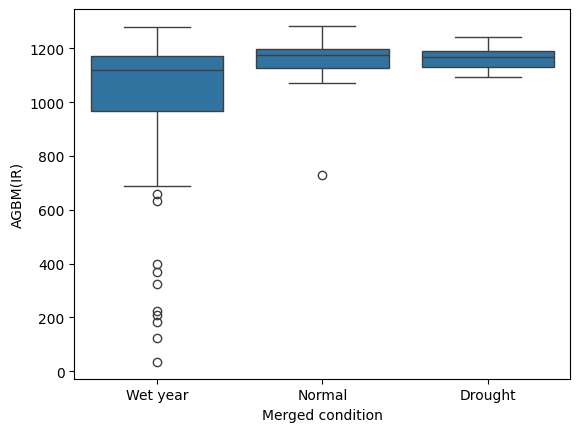

In [13]:
param = 'AGBM(IR)'
sns.boxplot(data= test[(test['State'].isin(major_corn_states))
            & (test[param]>00)].dropna(),x='Merged condition',y=param)

<Axes: xlabel='Merged condition', ylabel='AGBM(RF)'>

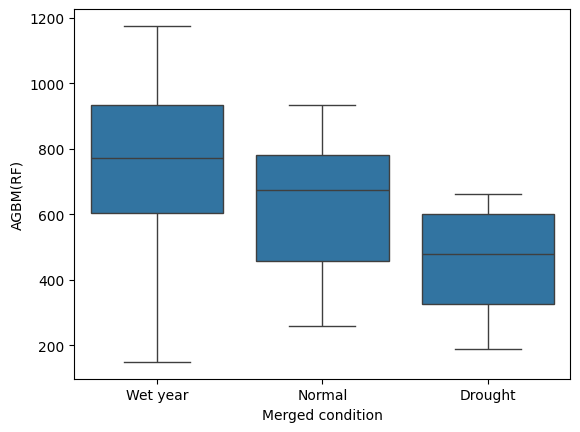

In [14]:
param = 'AGBM(RF)'
sns.boxplot(data= test[(test['State'].isin(major_corn_states))
            & (test[param]>00)].dropna(),x='Merged condition',y=param)

In [15]:
lp_abgm_ir = pd.read_excel(os.path.join(base,'LAI_irrigated_compiled.xlsx'))
lp_abgm_rf = pd.read_excel(os.path.join(base,'LAI_rainfed_compiled.xlsx'))
rs_gpp = pd.read_excel(os.path.join(base,'rs_lai_compiled.xlsx'))


lp_abgm_ir.rename(columns={'Mean(SO)':'LAI(IR)','State':'State_Name'},inplace=True)
lp_abgm_ir['year']=lp_abgm_ir['date'].apply(lambda x:x.year)
lp_abgm_ir['month']=lp_abgm_ir['date'].apply(lambda x:x.month)
lp_abgm_ir.drop(columns=['Unnamed: 0','date'],inplace=True)

lp_abgm_rf.rename(columns={'Mean(SO)':'LAI(RF)','State':'State_Name'},inplace=True)
lp_abgm_rf['year']=lp_abgm_rf['date'].apply(lambda x:x.year)
lp_abgm_rf['month']=lp_abgm_rf['date'].apply(lambda x:x.month)
lp_abgm_rf.drop(columns=['Unnamed: 0','date'],inplace=True)

lp_abgm_rf = gen_index(lp_abgm_rf)
lp_abgm_ir = gen_index(lp_abgm_ir)
rs_gpp = gen_index(rs_gpp)

gpp_compiled = pd.merge(lp_abgm_rf,lp_abgm_ir,on='ival')
gpp_compiled = pd.merge(gpp_compiled,rs_gpp,on='ival')

gpp_compiled['year']=gpp_compiled['ival'].apply(lambda x:int(x.split('-')[1]))
gpp_compiled['month']=gpp_compiled['ival'].apply(lambda x:int(x.split('-')[2]))
gpp_compiled['State']=gpp_compiled['ival'].apply(lambda x:(x.split('-')[0]))
gpp_compiled = gpp_compiled.set_index('ival')

In [16]:
pdsi_mnth = pd.read_excel(os.path.join(base,'PDSI_compiled.xlsx'))
pdsi_mnth.rename(columns={'State':'State_Name','Year':'year','Month':'month'},inplace=True)
pdsi_mnth = gen_index(pdsi_mnth)

In [17]:
lai = pd.merge(gpp_compiled,pdsi_mnth,on='ival')

In [18]:
lai_cs = lai[lai['month'].isin(range(4,10))]

In [19]:
lai_cs['Merged condition'] = lai_cs['Condition'].map(remap_condition)

In [20]:
palette = sns.color_palette("Spectral", as_cmap=True)

<Axes: xlabel='Merged condition', ylabel='LAI(RF)'>

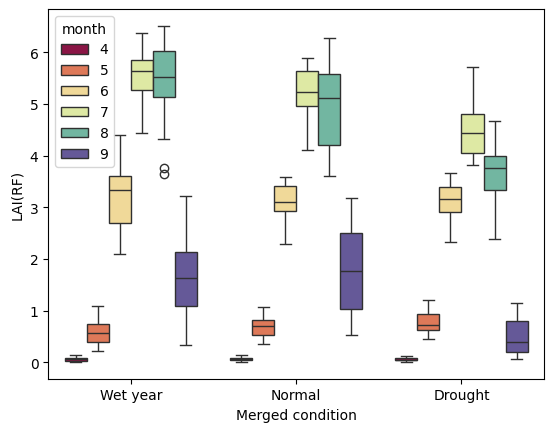

In [21]:
param = 'LAI(RF)'
test = lai_cs.copy()
sns.color_palette("tab10")
sns.boxplot(data= test[(test['State'].isin(major_corn_states))].dropna(),x='Merged condition',y=param,hue='month',palette=palette)

<Axes: xlabel='Merged condition', ylabel='LAI(IR)'>

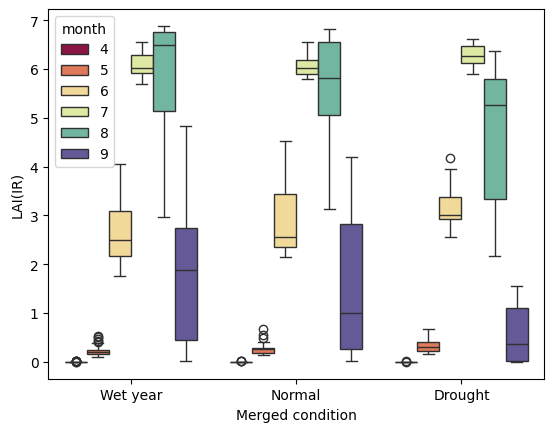

In [22]:
param = 'LAI(IR)'
test = lai_cs.copy()
sns.color_palette("tab10")
#   & (test['month']==8)
sns.boxplot(data= test[(test['State'].isin(major_corn_states))].dropna(),x='Merged condition',y=param,hue='month',palette=palette)

In [23]:
lp_abgm_ir = pd.read_excel(os.path.join(base,'C_so_pft_irrigated_compiled.xlsx'))
lp_abgm_rf = pd.read_excel(os.path.join(base,'C_so_pft_rainfed_compiled.xlsx'))
rs_gpp = pd.read_excel(os.path.join(base,'rs_gpp_compiled.xlsx'))

lp_abgm_ir.drop(columns=['Unnamed: 0'],inplace=True)
lp_abgm_rf.drop(columns=['Unnamed: 0'],inplace=True)

rs_gpp.drop(columns=['Unnamed: 0'],inplace=True)
rs_gpp.rename(columns={'mean':'GPP'},inplace=True)

lp_abgm_ir.rename(columns={'Mean(SO)':'SO(IR)','State':'State_Name'},inplace=True)
lp_abgm_rf.rename(columns={'Mean(SO)':'SO(RF)','State':'State_Name'},inplace=True)

lp_abgm_rf = gen_index(lp_abgm_rf)
lp_abgm_ir = gen_index(lp_abgm_ir)
rs_gpp = gen_index(rs_gpp)

gpp_compiled = pd.merge(lp_abgm_rf,lp_abgm_ir,on='ival')
gpp_compiled = pd.merge(gpp_compiled,rs_gpp,on='ival')

gpp_compiled['year']=gpp_compiled['ival'].apply(lambda x:int(x.split('-')[1]))
gpp_compiled['month']=gpp_compiled['ival'].apply(lambda x:int(x.split('-')[2]))
gpp_compiled['State']=gpp_compiled['ival'].apply(lambda x:(x.split('-')[0]))
gpp_compiled = gpp_compiled.set_index('ival')



In [34]:
carbon = pd.merge(gpp_compiled,pdsi_mnth,on='ival')
carbon_cs = carbon[carbon['month'].isin(range(4,10))]
carbon_cs['Merged condition'] = carbon_cs['Condition'].map(remap_condition)

<Axes: xlabel='Merged condition', ylabel='SO(RF)'>

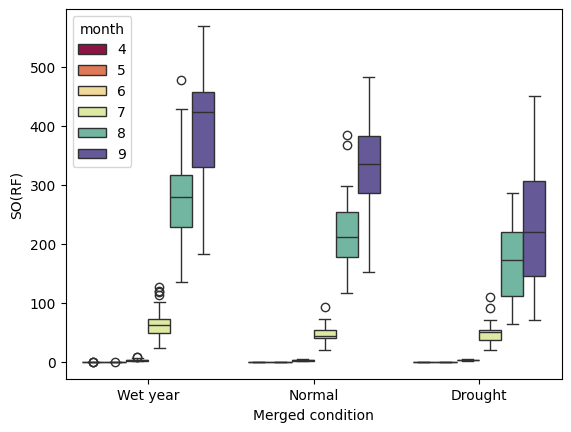

In [35]:
param = 'SO(RF)'
test = carbon_cs.copy()
sns.color_palette("tab10")
sns.boxplot(data= test[(test['State'].isin(major_corn_states))].dropna(),x='Merged condition',y=param,hue='month',palette=palette)

<Axes: xlabel='Merged condition', ylabel='SO(IR)'>

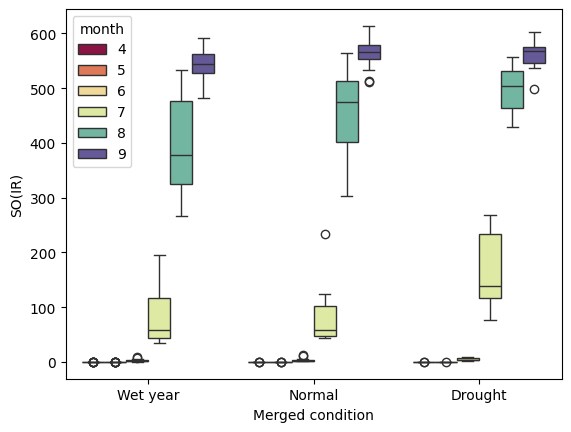

In [36]:
param = 'SO(IR)'
test = carbon_cs.copy()
sns.color_palette("tab10")
sns.boxplot(data= test[(test['State'].isin(major_corn_states))].dropna(),x='Merged condition',y=param,hue='month',palette=palette)

<Axes: xlabel='Merged condition', ylabel='GPP'>

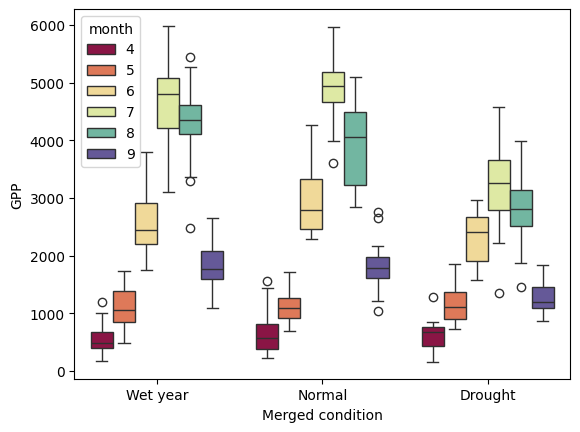

In [28]:
param = 'GPP'
test = carbon_cs.copy()
sns.color_palette("tab10")
sns.boxplot(data= test[(test['State'].isin(major_corn_states))].dropna(),x='Merged condition',y=param,hue='month',palette=palette)